# 42 — Multi-agent conviction: the stratified revolution / lock-in of §6

**What this is.** nb38 showed that a single agent's structural prune is a **conviction** decision:
prune edge `e` iff its evidence for redundancy clears its conviction protection, `ΔF_e > λ·v_e`
(value-tilted reduction, Eqs. 7–8; `v_e = U = T·u`). This notebook runs that **across a population**.
A community of agents shares the same regime-switching evidence but holds different convictions
`λ_i`, and we watch the spread of `λ` become the paper's **§6 order parameter**:

* **low-`λ` agents complete the revolution** — they prune the redundant structure, eliminating the
  contested phlogiston mass-law reading;
* **high-`λ` agents lock in** — they keep it past where the evidence alone would drop it;
* the population **never reaches structural consensus** — a fragmented field, the lock-in signature.

**Part B** adds the social channel: agents also differ in **evidence access** `γ` (a self-censored
disconfirming channel) and pool evidence over a **trust graph**. A low-conviction **vanguard** that
runs the refuting experiment can dissolve an evidence **bubble** (low `λ`, missing channel → converts
on exposure) but not an **echo chamber** (high `λ`, present channel → exposure can't move it) — the
paper's bubble-vs-echo (§6), and the statement that lock-in is a *conviction* phenomenon, not an
evidence-access one.

In [1]:
%matplotlib inline
import sys, pathlib
ROOT = pathlib.Path.cwd()
sys.path.insert(0, str(ROOT if (ROOT / 'src').exists() else ROOT.parent))
import numpy as np, jax, jax.numpy as jnp
import matplotlib.pyplot as plt
from matplotlib import cm
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.3})

from src.structural.phlogiston import (StructuralConfig, phlogiston_bn, gravimetric_H, gravimetric_rows,
                                       phi_true_at, conviction_u, balanced_lambda, DISAGREEMENT_NODES)
from src.structural.bayesnet import LinearGaussianBN
from src.structural import linalg, dual_field

RESULTS = pathlib.Path(ROOT if (ROOT / 'results').exists() else ROOT.parent) / 'results' / 'structural_multiagent_conviction'
RESULTS.mkdir(parents=True, exist_ok=True)
cfg = StructuralConfig(t_shift=40, n_steps=120)
bn = phlogiston_bn(cfg, conviction=2.0); names = bn.names; idx = {n: i for i, n in enumerate(names)}; d = bn.dim

# the over-wired incumbent paradigm (same as nb38) + the conviction protection field v_e
spurious = [('combustion_releases', 'mass_change_sign', 0.6), ('calcination_releases', 'reduction_with_charcoal', 0.6),
            ('air_has_capacity', 'respiration_like_combustion', 0.6), ('combustion_releases', 'calx_heavier_than_metal', 0.5)]
B = np.asarray(bn.B).copy()
for p, c, w in spurious: B[idx[c], idx[p]] = w
over = LinearGaussianBN(B=jnp.asarray(B), b=bn.b, s=bn.s, names=names); gbn = over.to_info()
edges = [(names[a], names[b]) for b in range(d) for a in range(d) if abs(B[b, a]) > 1e-9]
U = np.abs(np.asarray(dual_field.PrecisionUtilityNet(names=names, Pi=gbn.Pi, h=gbn.h,
                                                     u=conviction_u(cfg, 'phlogiston'), alpha=0.5).effective_utility()))
v_e = np.array([U[idx[p]] + U[idx[c]] for (p, c) in edges])           # conviction protection per edge
belt = [('mass_change_sign', 'calx_heavier_than_metal'), ('gas_consumed', 'calx_heavier_than_metal')]
belt_ix = [edges.index(e) for e in belt]
lstar = balanced_lambda(cfg, 'phlogiston')
print(f'{len(edges)} edges; contested belt (highest v_e): {[f"{p}→{c}" for p,c in belt]}; balanced λ* = {lstar:.2f}')

Hg = np.asarray(gravimetric_H(cfg)); rows = gravimetric_rows(cfg)
DISC = [i for i, r in enumerate(rows) if ('mass_balance' in r) or (r in DISAGREEMENT_NODES)]   # the disconfirming channel

14 edges; contested belt (highest v_e): ['mass_change_sign→calx_heavier_than_metal', 'gas_consumed→calx_heavier_than_metal']; balanced λ* = 0.69


## The shared evidence stream and the per-edge prune evidence over time

`dF_t[t, e]` is the closed-form BMR log Bayes factor for pruning edge `e` given the data through
step `t`. Computed once on the shared stream; each agent then just thresholds it against its own
`λ_i · v_e`.

In [2]:
def accumulate(gamma=0.0, seed=1):
    '''Accumulate the gravimetric Fisher deposit step by step; γ down-weights the disconfirming
    channel (self-censorship). Returns the per-step (J_t, j_t) likelihood trajectory.'''
    w = np.ones(Hg.shape[0])
    for i in DISC: w[i] = 1.0 - gamma
    Pi = jnp.zeros((d, d)); h = jnp.zeros(d); key = jax.random.PRNGKey(seed); Js, js = [], []
    for t in range(cfg.n_steps):
        phi = phi_true_at(cfg, t); key, k = jax.random.split(key)
        o = Hg @ phi + 0.1 * jax.random.normal(k, (Hg.shape[0],))
        Jd, jd = linalg.fisher_deposit_weighted(jnp.asarray(Hg), jnp.asarray(o), cfg.sigma_o, jnp.asarray(w))
        Pi = Pi + Jd; h = h + jd; Js.append(np.asarray(Pi)); js.append(np.asarray(h))
    return np.stack(Js), np.stack(js)

def dF_trace(Js, js):
    '''ΔF_t[t, e]: prune evidence for each edge at each step (BMR, no inversion of the prior).'''
    out = np.zeros((Js.shape[0], len(edges)))
    for t in range(Js.shape[0]):
        lik = (jnp.asarray(Js[t]), jnp.asarray(js[t]))
        for ei, (p, c) in enumerate(edges):
            out[t, ei] = float(over.bmr_prune_edge(c, p, likelihood=lik)['delta_F'])
    return out

Js, js = accumulate(gamma=0.0, seed=1)
dF_t = dF_trace(Js, js)                                               # (T, E) shared prune evidence
print('shared evidence: final ΔF per edge ranges', f'[{dF_t[-1].min():+.2f}, {dF_t[-1].max():+.2f}]')

shared evidence: final ΔF per edge ranges [-1.10, +1.29]


## A — A population with heterogeneous conviction (shared evidence)

`N` agents, convictions `λ_i` on a spectrum. Each commits, at each step, the edges its conviction
protects: `kept_i(t) = #{e : ΔF_e(t) ≤ λ_i v_e}`.

In [3]:
N = 80
lam = np.linspace(0.0, 1.6, N)                                       # conviction spectrum
# kept_i(t) and belt-cut (revolution) per agent over time, by thresholding the shared ΔF_t
kept = np.zeros((cfg.n_steps, N)); revolted = np.zeros((cfg.n_steps, N), bool)
for i in range(N):
    protect = lam[i] * v_e                                          # (E,) conviction protection
    pruned = dF_t > protect[None, :]                               # (T, E) bool
    kept[:, i] = (~pruned).sum(axis=1)
    revolted[:, i] = pruned[:, belt_ix].all(axis=1)               # both contested belt edges pruned
print(f'final edges kept: λ_min agent {kept[-1,0]:.0f}/{len(edges)} (revolution) … λ_max agent {kept[-1,-1]:.0f}/{len(edges)} (lock-in)')
print(f'final revolted fraction: {revolted[-1].mean():.2f}')

final edges kept: λ_min agent 2/14 (revolution) … λ_max agent 12/14 (lock-in)
final revolted fraction: 0.16


### A1 — The fan: edges kept over time, coloured by conviction

Each line is an agent. Low-conviction agents (blue) prune down toward the bare structure as the
evidence accumulates; high-conviction agents (red) hold their over-wired net. The population fans
apart — same evidence, different convictions.

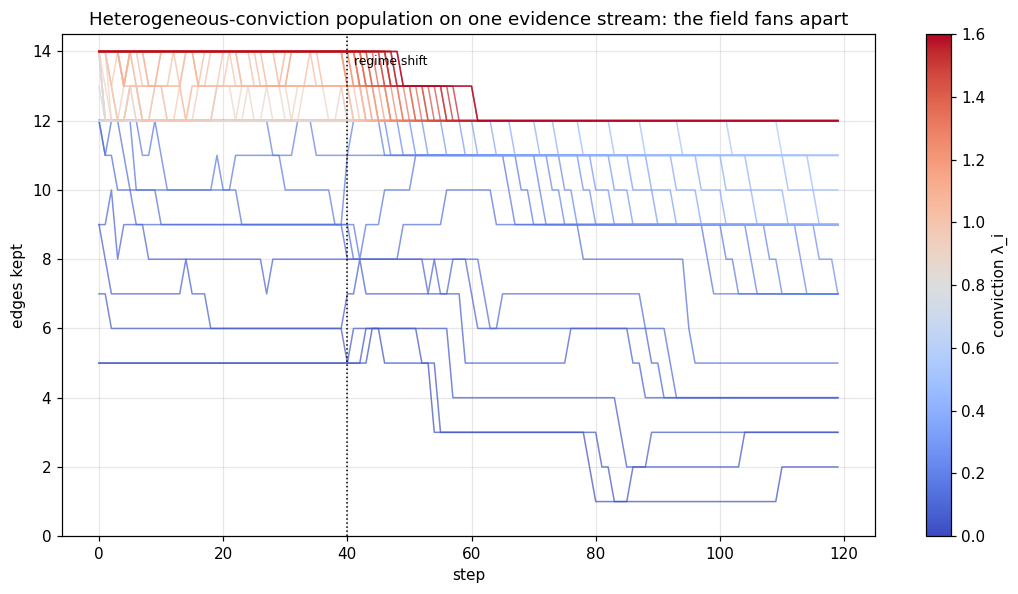

In [4]:
fig, ax = plt.subplots(figsize=(10, 5.5))
cmap = cm.coolwarm
for i in range(N):
    ax.plot(kept[:, i], color=cmap(lam[i] / lam.max()), lw=1.0, alpha=0.7)
ax.axvline(cfg.t_shift, color='k', ls=':', lw=1); ax.text(cfg.t_shift+1, len(edges)-0.4, 'regime shift', fontsize=8)
sm = cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(lam.min(), lam.max())); sm.set_array([])
fig.colorbar(sm, ax=ax, label='conviction λ_i')
ax.set_xlabel('step'); ax.set_ylabel('edges kept'); ax.set_ylim(0, len(edges)+0.5)
ax.set_title('Heterogeneous-conviction population on one evidence stream: the field fans apart')
plt.tight_layout(); plt.savefig(RESULTS / 'A1_conviction_fan.png'); plt.show()

### A2 — The stratified order parameter: final structure vs conviction

The §6 picture. Final edges kept (and whether the contested belt survived) as a function of `λ_i`.
Below the threshold the agents complete the revolution (prune the contested mass-law structure);
above it they lock in. The crossing is the model's sharpest prediction — *conviction sets whether the
core ever moves*.

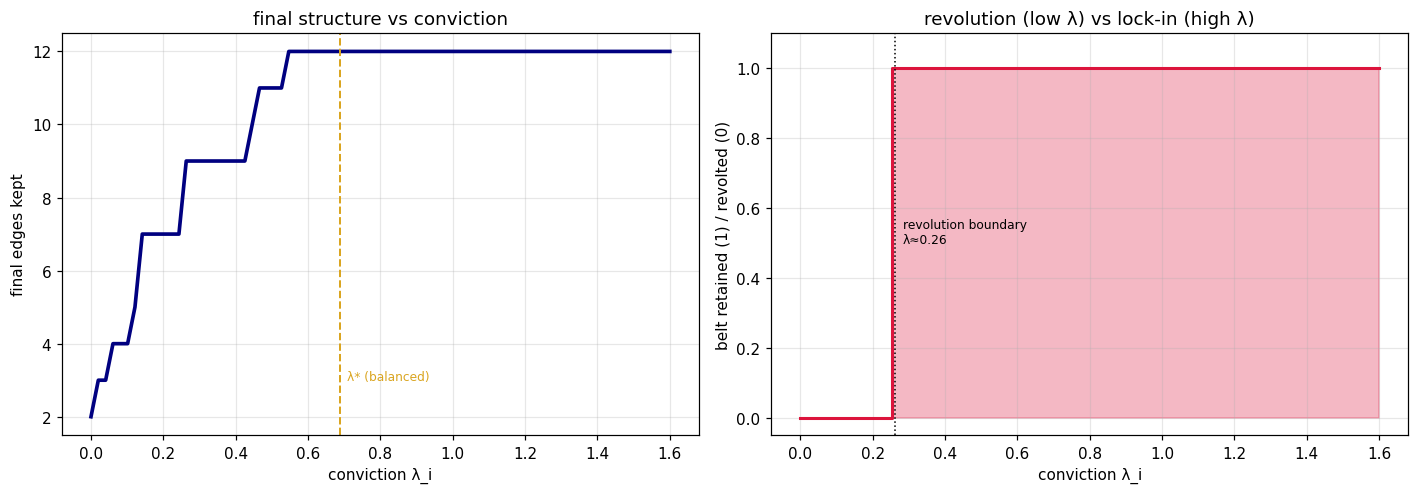

revolution boundary at λ ≈ 0.26; below it the contested core is eliminated, above it it stalls.


In [5]:
fig, (a0, a1) = plt.subplots(1, 2, figsize=(13, 4.6))
a0.plot(lam, kept[-1], lw=2.4, color='navy'); a0.axvline(lstar, color='goldenrod', ls='--', lw=1.3)
a0.text(lstar+0.02, kept[-1].min()+1, 'λ* (balanced)', color='goldenrod', fontsize=8)
a0.set_xlabel('conviction λ_i'); a0.set_ylabel('final edges kept'); a0.set_title('final structure vs conviction')
belt_alive = ~revolted[-1]
a1.fill_between(lam, 0, belt_alive.astype(float), step='mid', color='crimson', alpha=0.3, label='contested belt retained')
a1.plot(lam, belt_alive.astype(float), drawstyle='steps-mid', color='crimson', lw=2)
thr = lam[np.argmax(belt_alive)] if belt_alive.any() else None
if thr is not None: a1.axvline(thr, color='k', ls=':', lw=1); a1.text(thr+0.02, 0.5, f'revolution boundary\nλ≈{thr:.2f}', fontsize=8)
a1.set_xlabel('conviction λ_i'); a1.set_ylabel('belt retained (1) / revolted (0)'); a1.set_ylim(-0.05, 1.1)
a1.set_title('revolution (low λ) vs lock-in (high λ)')
plt.tight_layout(); plt.savefig(RESULTS / 'A2_stratified_order_parameter.png'); plt.show()
print(f'revolution boundary at λ ≈ {thr:.2f}; below it the contested core is eliminated, above it it stalls.')

### A3 — Stratified conversion and persistent disagreement

Left: the fraction of each conviction tertile that has completed the revolution over time —
skeptics convert, the high-conviction core never does (the stall). Right: the population's
**structural disagreement** (spread in edges kept) — it *stays high*, the field never reaches
consensus: a community split by conviction, not by evidence.

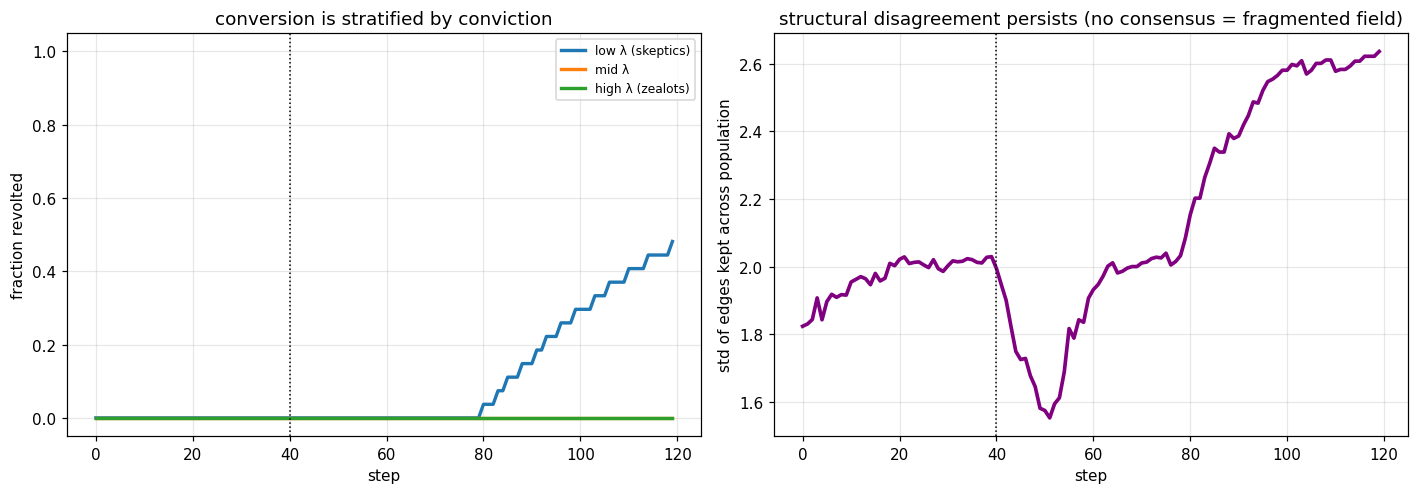

final per-tertile revolted fraction: {'low λ (skeptics)': 0.48, 'mid λ': 0.0, 'high λ (zealots)': 0.0}
structural disagreement (std kept): start 1.82 -> end 2.64 (stays > 0)


In [6]:
tertiles = [('low λ (skeptics)', lam <= np.quantile(lam, 1/3)),
            ('mid λ', (lam > np.quantile(lam, 1/3)) & (lam <= np.quantile(lam, 2/3))),
            ('high λ (zealots)', lam > np.quantile(lam, 2/3))]
fig, (a0, a1) = plt.subplots(1, 2, figsize=(13, 4.6))
for label, mask in tertiles:
    a0.plot(revolted[:, mask].mean(axis=1), lw=2.2, label=label)
a0.axvline(cfg.t_shift, color='k', ls=':', lw=1); a0.set_ylim(-0.05, 1.05)
a0.set_xlabel('step'); a0.set_ylabel('fraction revolted'); a0.set_title('conversion is stratified by conviction')
a0.legend(fontsize=8)
a1.plot(kept.std(axis=1), lw=2.4, color='purple')
a1.axvline(cfg.t_shift, color='k', ls=':', lw=1)
a1.set_xlabel('step'); a1.set_ylabel('std of edges kept across population')
a1.set_title('structural disagreement persists (no consensus = fragmented field)')
plt.tight_layout(); plt.savefig(RESULTS / 'A3_stratified_and_disagreement.png'); plt.show()
print('final per-tertile revolted fraction:', {l: round(float(revolted[-1, m].mean()), 2) for l, m in tertiles})
print(f'structural disagreement (std kept): start {kept.std(axis=1)[0]:.2f} -> end {kept.std(axis=1)[-1]:.2f} (stays > 0)')

## B — Bubble vs echo chamber: can a vanguard's evidence dissolve lock-in?

Now agents differ in **evidence access** too. We build three blocs and a low-conviction
**vanguard** that runs the refuting experiment (`γ = 0`), then pool evidence over a trust graph
(`isolated` = no inter-bloc links; `connected` = each bloc trusts the vanguard). The question: does
exposure to the vanguard's disconfirming evidence dissolve the blocs' lock-in?

* **bubble** — *low* conviction, *missing* channel (`γ` high): stalled for lack of evidence;
* **echo chamber** — *high* conviction, channel *present* (`γ = 0`): stalled by value.

In [7]:
blocs = {'vanguard':    dict(gamma=0.0,  lam=0.10, n=20, seed=10),
         'bubble':      dict(gamma=0.95, lam=0.15, n=20, seed=20),
         'echo chamber':dict(gamma=0.0,  lam=1.50, n=20, seed=30)}
# each bloc's accumulated final evidence (mean over its members' streams)
def bloc_evidence(spec):
    Js_, js_ = [], []
    for s in range(spec['n']):
        J, j = accumulate(gamma=spec['gamma'], seed=spec['seed'] + s)
        Js_.append(J[-1]); js_.append(j[-1])
    return np.mean(Js_, axis=0), np.mean(js_, axis=0)
ev = {name: bloc_evidence(spec) for name, spec in blocs.items()}

def belt_cut(J, j, lam_):
    return all(float(over.bmr_prune_edge(c, p, likelihood=(jnp.asarray(J), jnp.asarray(j)))['delta_F']) > lam_ * v_e[edges.index((p, c))]
               for (p, c) in belt)

# isolated: each bloc on its own evidence; connected: 50/50 pool with the vanguard's evidence
Jv, jv = ev['vanguard']
res = {}
for name in ['bubble', 'echo chamber']:
    J, j = ev[name]; lam_ = blocs[name]['lam']
    iso = belt_cut(J, j, lam_)
    con = belt_cut(0.5 * J + 0.5 * Jv, 0.5 * j + 0.5 * jv, lam_)
    res[name] = (iso, con)
    print(f'{name:13s} (γ={blocs[name]["gamma"]}, λ={blocs[name]["lam"]}): isolated revolted={iso}  ->  connected-to-vanguard revolted={con}')

bubble        (γ=0.95, λ=0.15): isolated revolted=False  ->  connected-to-vanguard revolted=True
echo chamber  (γ=0.0, λ=1.5): isolated revolted=False  ->  connected-to-vanguard revolted=False


### B1 — The result: exposure dissolves the bubble, not the echo chamber

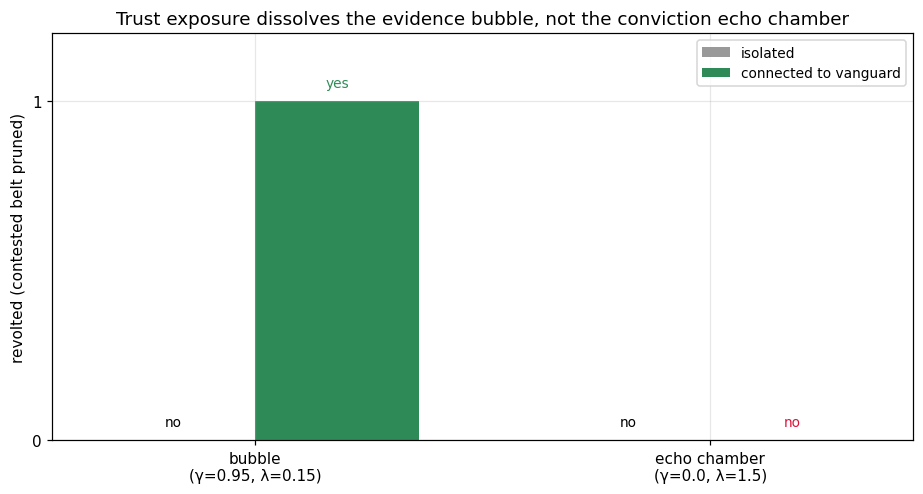

In [8]:
fig, ax = plt.subplots(figsize=(8.5, 4.6))
groups = ['bubble', 'echo chamber']; x = np.arange(len(groups)); wbar = 0.36
iso_vals = [1.0 if res[g][0] else 0.0 for g in groups]
con_vals = [1.0 if res[g][1] else 0.0 for g in groups]
ax.bar(x - wbar/2, iso_vals, wbar, label='isolated', color='0.6')
ax.bar(x + wbar/2, con_vals, wbar, label='connected to vanguard', color='seagreen')
ax.set_xticks(x); ax.set_xticklabels([f'{g}\n(γ={blocs[g]["gamma"]}, λ={blocs[g]["lam"]})' for g in groups])
ax.set_ylabel('revolted (contested belt pruned)'); ax.set_ylim(0, 1.2); ax.set_yticks([0, 1])
ax.set_title('Trust exposure dissolves the evidence bubble, not the conviction echo chamber')
ax.legend(loc='upper right', fontsize=9)
for xi, g in zip(x, groups):
    ax.text(xi - wbar/2, iso_vals[groups.index(g)] + 0.04, 'no' if not res[g][0] else 'yes', ha='center', fontsize=9)
    ax.text(xi + wbar/2, con_vals[groups.index(g)] + 0.04, 'yes' if res[g][1] else 'no', ha='center', fontsize=9,
            color='seagreen' if res[g][1] else 'crimson')
plt.tight_layout(); plt.savefig(RESULTS / 'B1_bubble_vs_echo.png'); plt.show()

## Verdict

The conviction-gated reduction of nb38, run across a population, reproduces the paper's §6:

* **stratified revolution / lock-in** (§A) — one evidence stream, a spread of convictions `λ_i`: the
  low-`λ` agents prune the redundant contested structure (revolution), the high-`λ` agents keep it
  (lock-in), and the population fans apart with a sharp **revolution boundary** in `λ`. Structural
  disagreement **persists** — the field never reaches consensus, split by conviction not evidence;
* **bubble vs echo chamber** (§B) — a low-conviction vanguard's disconfirming evidence, shared over a
  trust graph, **dissolves the bubble** (missing channel, low conviction → converts) but **not the
  echo chamber** (present channel, high conviction → unmoved). Lock-in is a **conviction**
  phenomenon: honest agents with the truth in reach still stall.

The through-line of nb38–42: structure learning is **expansion and reduction over a Bayes net**
(nb38 remove / nb39 add / nb40 both / nb41 init-sensitivity), and **how much a community revises is
set by conviction** — the same `λ` that vetoes a single agent's prune, spread over a population,
*is* the order parameter that separates a scientific revolution from an evidential lock-in.